# Prediction with linear regression models


In [1]:
#import modules and data
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('reg_ex.csv',sep = ';')
df.head()

,x,y
0,23,1020
1,17,682
2,142,8403
3,44,1325
4,97,4472


In [2]:
df.describe()

,x,y
count,33.000000,33.000000
mean,57.515152,2752.969697
std,40.519379,2603.418240
min,15.000000,246.000000
25%,23.000000,829.000000
50%,44.000000,1798.000000
75%,92.000000,4393.000000
max,142.000000,11992.000000


## Regression parameters

In [3]:
# Regression parameters
y = np.array(df['y']) # dependent
x = np.array(df['x']).reshape((-1, 1)) # independent

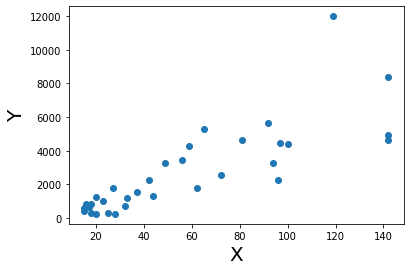

In [4]:
plt.scatter(x,y)
plt.xlabel('X', fontsize = 20)
plt.ylabel('Y', fontsize = 20)
plt.show()

## Linear Regression

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
x_train, x_test, y_train, y_test = train_test_split(x, y)
model = LinearRegression().fit(x_train, y_train)
y_1 = model.predict(x_test)

In [6]:
from sklearn.metrics import r2_score
print("R^2: ", r2_score(y_test,y_1))

R^2:  0.6115787518421891


# Ridge Regression

In [8]:
from sklearn.linear_model import Ridge
model2 = Ridge(alpha=1).fit(x_train, y_train)
y_2 = model2.predict(x_test)
print("R^2: ", r2_score(y_test,y_2))

R^2:  0.6115810111533515


In [9]:
from sklearn.model_selection import cross_val_score
cv_1= cross_val_score(model,x,y, cv = 10)
print(cv_1)
cv_1 = np.absolute(cv_1)
print('Mean MAE: %.3f (%.3f)' % (np.mean(cv_1), np.std(cv_1)))

[ 0.93374811  0.7870949  -2.17960763  0.19400653  0.58660727 -7.74104352
  0.9218209   0.24475632  0.62231306  0.33119524]
Mean MAE: 1.454 (2.163)


In [10]:
cv_2= cross_val_score(model2,x,y, cv = 10)
print(cv_2)
cv_2 = np.absolute(cv_2)
print('Mean MAE: %.3f (%.3f)' % (np.mean(cv_2), np.std(cv_2)))

[ 0.93374036  0.78708874 -2.17948202  0.19406149  0.58660119 -7.74089597
  0.92183018  0.24480197  0.62231264  0.33118274]
Mean MAE: 1.454 (2.163)


## Lasso Regression 

In [11]:
from sklearn.linear_model import Lasso
model3 = Ridge(alpha=1).fit(x_train, y_train)
y_3 = model3.predict(x_test)
print("R^2: ", r2_score(y_test,y_3))

R^2:  0.6115810111533515


# You can notice that for univariate regression Ridge, Lasso and Linear Regression show us the same result !